# Caso real: detecção de fraude

**Tema:** Aprendizado Não Supervisionado › Detecção de Anomalias

Um emissor de cartões processa 1.000 transações por dia e tem um time que
consegue investigar **3 alertas por dia**. Temos 60 dias de histórico. Nos
primeiros 40 dias aparecem dois tipos de fraude conhecidos; nos últimos
20, surge um terceiro tipo que **nunca** tinha aparecido. Este notebook
compara, no período de teste, um modelo supervisionado treinado com o
histórico, um detector não supervisionado e as formas de combiná-los —
medindo tudo no orçamento de alertas do time.

Os dados são sintéticos; a coluna `tipo` existe só para a análise por tipo
de fraude, e nenhum modelo a usa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Os dados

Além das transações legítimas comuns, há comportamentos legítimos **porém
incomuns** — viagens, compras grandes, dispositivos compartilhados pela
família, contas recém-abertas, compras de madrugada, rajadas de compras.
São eles que tornam a detecção difícil: um detector de anomalias vai
achá-los estranhos, e com razão.

In [2]:
def gera_transacoes(semente=2025, n=60000, n_clientes=3000, dias=60):
    rng = np.random.default_rng(semente)
    valor_medio = rng.lognormal(np.log(120), 0.6, n_clientes)
    idade_inicial = rng.exponential(500, n_clientes) + 1
    cli = rng.integers(0, n_clientes, n)
    dia = rng.integers(0, dias, n)
    hora = np.clip(rng.normal(14, 4.5, n), 0, 23.99)
    valor = valor_medio[cli] * rng.lognormal(0, 0.5, n)
    dist = rng.exponential(8, n)
    n1h = rng.poisson(0.3, n) + 1
    disp_novo = (rng.random(n) < 0.03).astype(int)
    idade = idade_inicial[cli] + dia
    n_cart = 1 + (rng.random(n) < 0.05).astype(int)
    # comportamentos legítimos, porém incomuns
    u = rng.random(n)
    viagem = u < 0.03
    dist[viagem] = rng.uniform(300, 3000, viagem.sum())
    disp_novo[viagem] = (rng.random(viagem.sum()) < 0.3).astype(int)
    grande = (u >= 0.03) & (u < 0.05)
    valor[grande] = valor_medio[cli[grande]] * rng.uniform(5, 15, grande.sum())
    familia = (u >= 0.05) & (u < 0.07)
    n_cart[familia] = 2 + rng.poisson(2, familia.sum())
    nova = (u >= 0.07) & (u < 0.09)
    idade[nova] = rng.uniform(1, 30, nova.sum())
    disp_novo[nova] = (rng.random(nova.sum()) < 0.7).astype(int)
    madrugada = (u >= 0.09) & (u < 0.13)
    hora[madrugada] = rng.uniform(0, 5, madrugada.sum())
    rajada = (u >= 0.13) & (u < 0.15)
    n1h[rajada] = rng.poisson(4, rajada.sum()) + 2
    tipo = np.array(["legítima"] * n, dtype=object)
    # fraude A — cartão clonado: valor alto para o cliente, longe de casa, muitas vezes de madrugada
    a = rng.choice(n, 100, replace=False)
    tipo[a] = "A: cartão clonado"
    valor[a] = valor_medio[cli[a]] * rng.uniform(3, 8, len(a))
    dist[a] = rng.uniform(50, 1500, len(a))
    noite = rng.random(len(a)) < 0.6
    hora[a] = np.where(noite, rng.uniform(0, 5, len(a)), rng.uniform(8, 22, len(a)))
    disp_novo[a] = (rng.random(len(a)) < 0.5).astype(int)
    # fraude B — teste de cartão: rajada de compras pequenas
    b = rng.choice(np.setdiff1d(np.arange(n), a), 80, replace=False)
    tipo[b] = "B: teste de cartão"
    valor[b] = rng.uniform(1, 15, len(b))
    n1h[b] = rng.poisson(5, len(b)) + 3
    disp_novo[b] = (rng.random(len(b)) < 0.8).astype(int)
    # fraude C — conta laranja: SÓ nos últimos 20 dias. Conta nova, vários cartões no mesmo aparelho
    livres = np.setdiff1d(np.where(dia >= 40)[0], np.r_[a, b])
    c = rng.choice(livres, 60, replace=False)
    tipo[c] = "C: conta laranja"
    idade[c] = rng.uniform(1, 30, len(c))
    n_cart[c] = 2 + rng.poisson(2, len(c))
    valor[c] = valor_medio[cli[c]] * rng.uniform(1.2, 3, len(c))
    disp_novo[c] = (rng.random(len(c)) < 0.8).astype(int)
    df = pd.DataFrame({
        "cliente": cli, "dia": dia, "hora": hora.round(2), "valor": valor.round(2),
        "razao_valor": (valor / valor_medio[cli]).round(3), "dist_casa_km": dist.round(1),
        "n_trans_1h": n1h, "dispositivo_novo": disp_novo, "idade_conta_dias": idade.round(0),
        "n_cartoes_no_dispositivo": n_cart, "tipo": tipo})
    df["fraude"] = (df["tipo"] != "legítima").astype(int)
    return df.sort_values(["dia", "hora"]).reset_index(drop=True)


df = gera_transacoes()
features = ["hora", "valor", "razao_valor", "dist_casa_km", "n_trans_1h", "dispositivo_novo",
            "idade_conta_dias", "n_cartoes_no_dispositivo"]
print(df[features].describe().round(2).T.to_string())
print("\nfraudes por tipo e período:")
print(pd.crosstab(df["tipo"], np.where(df["dia"] < 40, "treino (dias 0-39)", "teste (dias 40-59)")))

                            count    mean     std   min     25%     50%     75%      max
hora                      60000.0   13.51    4.92  0.00   10.50   13.76   16.88    23.99
valor                     60000.0  187.77  280.02  1.05   71.13  121.31  209.30  9881.51
razao_valor               60000.0    1.32    1.46  0.01    0.72    1.01    1.44    15.00
dist_casa_km              60000.0   58.28  312.24  0.00    2.40    5.80   11.90  2996.40
n_trans_1h                60000.0    1.40    0.92  1.00    1.00    1.00    2.00    13.00
dispositivo_novo          60000.0    0.05    0.23  0.00    0.00    0.00    0.00     1.00
idade_conta_dias          60000.0  519.10  500.26  1.00  162.00  363.00  717.00  5556.00
n_cartoes_no_dispositivo  60000.0    1.11    0.52  1.00    1.00    1.00    1.00    11.00

fraudes por tipo e período:
col_0               teste (dias 40-59)  treino (dias 0-39)
tipo                                                      
A: cartão clonado                   33              

## 2. Preparação e divisão temporal

Divisão **temporal**, nunca aleatória: o modelo é treinado com os 40
primeiros dias e avaliado nos 20 seguintes — exatamente como vai operar.
As colunas de cauda longa passam por log.

In [3]:
X = df[features].copy()
for col in ["valor", "razao_valor", "dist_casa_km", "idade_conta_dias"]:
    X[col] = np.log1p(X[col])
treino, teste = (df["dia"] < 40).to_numpy(), (df["dia"] >= 40).to_numpy()
X_tr, X_te = X[treino], X[teste]
y_tr, y_te = df["fraude"][treino].to_numpy(), df["fraude"][teste].to_numpy()
tipo_te = df["tipo"][teste].to_numpy()
ORCAMENTO = 60  # 3 alertas/dia x 20 dias
print(f"teste: {teste.sum()} transações, {y_te.sum()} fraudes | orçamento: {ORCAMENTO} alertas")

def relatorio(nome, escore, k=ORCAMENTO):
    ordem = np.argsort(escore)[::-1][:k]
    linha = {"estratégia": nome,
             "PR-AUC": average_precision_score(y_te, escore),
             f"precisão@{k}": y_te[ordem].mean(),
             f"recall@{k}": y_te[ordem].sum() / y_te.sum()}
    for t in ["A: cartão clonado", "B: teste de cartão", "C: conta laranja"]:
        linha[f"recall {t[0]}"] = np.isin(np.where(tipo_te == t)[0], ordem).mean()
    return linha

teste: 19867 transações, 119 fraudes | orçamento: 60 alertas


## 3. Modelo supervisionado treinado com o histórico

In [4]:
gb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, class_weight="balanced",
                                    random_state=0).fit(X_tr, y_tr)
escore_gb = gb.predict_proba(X_te)[:, 1]
resultados = [relatorio("supervisionado (boosting)", escore_gb)]
print(pd.DataFrame(resultados).round(3).to_string(index=False))

               estratégia  PR-AUC  precisão@60  recall@60  recall A  recall B  recall C
supervisionado (boosting)   0.517         0.85      0.429     0.848     0.885       0.0


O modelo supervisionado é excelente nos tipos que conhece (A e B) e
**cego** para o tipo C — ele nunca viu uma conta laranja, então nada no
treino ensinou que "conta nova com vários cartões no mesmo aparelho" é
suspeito.

## 4. Detector não supervisionado

Isolation Forest treinado nas transações do período de treino (sem
rótulo nenhum), aplicado ao teste.

In [5]:
iforest = IsolationForest(n_estimators=300, random_state=0).fit(X_tr)
escore_if = -iforest.score_samples(X_te)
resultados.append(relatorio("não supervisionado (Isolation Forest)", escore_if))
print(pd.DataFrame(resultados).round(3).to_string(index=False))

                           estratégia  PR-AUC  precisão@60  recall@60  recall A  recall B  recall C
            supervisionado (boosting)   0.517        0.850      0.429     0.848     0.885     0.000
não supervisionado (Isolation Forest)   0.775        0.933      0.471     0.212     0.538     0.583


O Isolation Forest não sabe o que é fraude: ele sabe o que é **estranho**.
Encontra parte das fraudes de todos os tipos — inclusive mais da metade
das C, que o supervisionado não via —, mas perde a maior parte das A: um
cartão clonado usado longe de casa, com valor alto, se parece com as
viagens e compras grandes legítimas, e não é estranho o bastante para
chegar ao topo da fila. Note também o PR-AUC: neste período, em que metade
das fraudes é de um tipo novo, o detector sem rótulo supera o modelo
supervisionado — o retrato de por que confiar só no supervisionado é
arriscado num domínio adversarial.

## 5. Combinando os dois

Três formas de combinar, sempre com o mesmo orçamento de 60 alertas:

1. **Escore não supervisionado como feature** do modelo supervisionado.
2. **Média de ranks** dos dois escores.
3. **Duas filas**: a maior parte do orçamento para o supervisionado e uma
   fila menor para os casos mais estranhos que o supervisionado **não**
   colocou na sua fila.

In [6]:
# 1. escore do IF como feature (calculado com o IF treinado só no período de treino)
X_tr_aug = X_tr.assign(escore_if=-iforest.score_samples(X_tr))
X_te_aug = X_te.assign(escore_if=escore_if)
gb_aug = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, class_weight="balanced",
                                        random_state=0).fit(X_tr_aug, y_tr)
resultados.append(relatorio("IF como feature do boosting", gb_aug.predict_proba(X_te_aug)[:, 1]))

# 2. média de ranks
rank = lambda s: pd.Series(s).rank(pct=True).to_numpy()
resultados.append(relatorio("média de ranks", (rank(escore_gb) + rank(escore_if)) / 2))

# 3. duas filas: 45 alertas do supervisionado + 15 do IF entre os que sobraram
def duas_filas(s_sup, s_nao, k_sup, k_total=ORCAMENTO):
    fila_sup = np.argsort(s_sup)[::-1][:k_sup]
    restantes = np.setdiff1d(np.arange(len(s_sup)), fila_sup)
    fila_nao = restantes[np.argsort(s_nao[restantes])[::-1][:k_total - k_sup]]
    escore = np.zeros(len(s_sup))
    escore[fila_nao] = 1
    escore[fila_sup] = 2
    return escore

resultados.append(relatorio("duas filas (45 + 15)", duas_filas(escore_gb, escore_if, 45)))
tabela = pd.DataFrame(resultados).set_index("estratégia")
print(tabela.drop(columns="PR-AUC").round(3).to_string())

                                       precisão@60  recall@60  recall A  recall B  recall C
estratégia                                                                                 
supervisionado (boosting)                    0.850      0.429     0.848     0.885     0.000
não supervisionado (Isolation Forest)        0.933      0.471     0.212     0.538     0.583
IF como feature do boosting                  0.883      0.445     0.909     0.885     0.000
média de ranks                               0.833      0.420     0.667     0.846     0.100
duas filas (45 + 15)                         0.967      0.487     0.788     0.769     0.200


**Leitura esperada:** o escore do IF como feature **não** resolve o tipo
C — o modelo supervisionado só aprende a usar uma feature para os padrões
que estão no treino, e no treino não há conta laranja. A média de ranks
decepciona: ela **dilui** os dois sinais — uma conta laranja tem rank alto
no IF e baixo no supervisionado, e a média a deixa no meio da fila, fora
do orçamento. As duas filas são a melhor estratégia das cinco: maior
precisão e maior recall no orçamento, com a maior parte da cobertura de A
e B preservada e uma parte das C recuperada. Cada sinal manda na sua
própria fila, em vez de um diluir o outro. (O PR-AUC foi omitido desta
tabela porque, na estratégia de duas filas, o "escore" só ordena os
alertas escolhidos — ele não é uma pontuação contínua.)

## 6. Quanto do orçamento dar a cada fila?

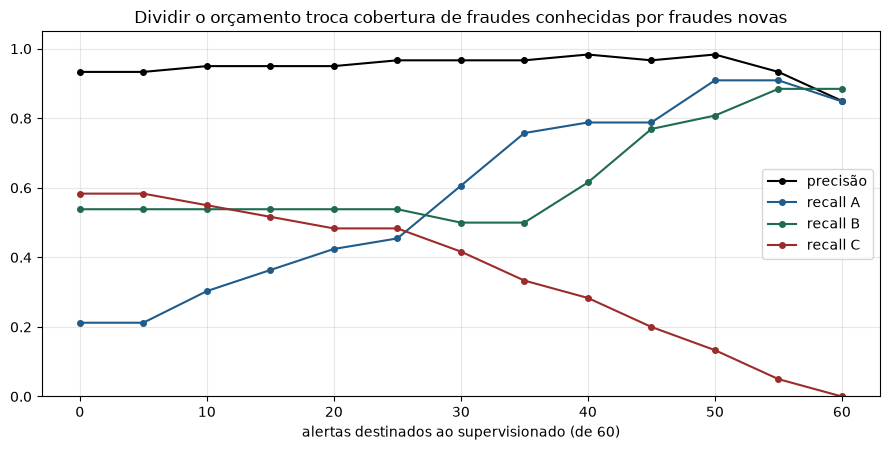

                           precisão  recall A  recall B  recall C
alertas do supervisionado                                        
0                              0.93      0.21      0.54      0.58
5                              0.93      0.21      0.54      0.58
10                             0.95      0.30      0.54      0.55
15                             0.95      0.36      0.54      0.52
20                             0.95      0.42      0.54      0.48
25                             0.97      0.45      0.54      0.48
30                             0.97      0.61      0.50      0.42
35                             0.97      0.76      0.50      0.33
40                             0.98      0.79      0.62      0.28
45                             0.97      0.79      0.77      0.20
50                             0.98      0.91      0.81      0.13
55                             0.93      0.91      0.88      0.05
60                             0.85      0.85      0.88      0.00


In [7]:
linhas = []
for k_sup in range(0, ORCAMENTO + 1, 5):
    r = relatorio("", duas_filas(escore_gb, escore_if, k_sup))
    linhas.append({"alertas do supervisionado": k_sup, "precisão": r[f"precisão@{ORCAMENTO}"],
                   "recall A": r["recall A"], "recall B": r["recall B"], "recall C": r["recall C"]})
divisao = pd.DataFrame(linhas).set_index("alertas do supervisionado")
fig, ax = plt.subplots(figsize=(9, 4.6))
for col, cor in [("precisão", "black"), ("recall A", AZUL), ("recall B", VERDE), ("recall C", VERMELHO)]:
    ax.plot(divisao.index, divisao[col], "o-", color=cor, label=col, ms=4)
ax.set_xlabel(f"alertas destinados ao supervisionado (de {ORCAMENTO})")
ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("Dividir o orçamento troca cobertura de fraudes conhecidas por fraudes novas")
plt.tight_layout(); plt.show()
print(divisao.round(2).to_string())

Não existe divisão "ótima" universal: é uma decisão sobre quanto risco de
fraude **nova** o negócio aceita correr para não perder fraudes
**conhecidas**. Na prática, a fila não supervisionada costuma ficar com
10–30% do orçamento e funciona como um **sistema de alerta precoce**.

## 7. O ciclo de feedback: a fraude nova vira fraude conhecida

Suponha que a fila não supervisionada revelou as contas laranja nos dias
40–49, e os casos investigados viraram rótulos. Retreinamos o
supervisionado com os dias 0–49 e avaliamos só nos dias 50–59.

In [8]:
treino2, teste2 = (df["dia"] < 50).to_numpy(), (df["dia"] >= 50).to_numpy()
gb2 = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, class_weight="balanced",
                                     random_state=0).fit(X[treino2], df["fraude"][treino2])
y_te2, tipo_te2 = df["fraude"][teste2].to_numpy(), df["tipo"][teste2].to_numpy()
k2 = 30  # 3 alertas/dia x 10 dias
print(f"dias 50-59: {y_te2.sum()} fraudes, das quais {(tipo_te2 == 'C: conta laranja').sum()} "
      f"são contas laranja; orçamento de {k2} alertas")
for nome, modelo in [("treinado até o dia 39", gb), ("retreinado até o dia 49", gb2)]:
    s = modelo.predict_proba(X[teste2])[:, 1]
    top = np.argsort(s)[::-1][:k2]
    rec_c = np.isin(np.where(tipo_te2 == "C: conta laranja")[0], top).mean()
    print(f"{nome:>24s}: precisão@{k2} = {y_te2[top].mean():.2f} | recall do tipo C = {rec_c:.2f}")

dias 50-59: 57 fraudes, das quais 25 são contas laranja; orçamento de 30 alertas
   treinado até o dia 39: precisão@30 = 0.87 | recall do tipo C = 0.00
 retreinado até o dia 49: precisão@30 = 0.97 | recall do tipo C = 0.28


Com alguns exemplos rotulados, o supervisionado passa a reconhecer o
padrão novo: as contas laranja entram na fila e a precisão sobe. O recall
de C não chega perto de 1 porque o orçamento de 30 alertas é menor que o
número de fraudes do período — as contas laranja agora **disputam** a
fila com as fraudes conhecidas, que é exatamente o que se quer. E a fila
não supervisionada fica livre para vigiar a **próxima** novidade.
Esse ciclo (estranho → investigado → rotulado → aprendido) é o motor de
um sistema de fraude em produção.

## O que levar deste notebook

- Supervisionado é o componente mais preciso para fraudes conhecidas e é
  cego para fraudes novas.
- Não supervisionado encontra o estranho — incluindo o legítimo incomum —
  e é o alerta precoce para o que ainda não tem rótulo.
- Usar o escore não supervisionado **só** como feature não resolve fraudes
  novas; uma fila própria (ou uma combinação de ranks) resolve em parte.
- Tudo se mede no orçamento de alertas, com divisão temporal.
- O ciclo de feedback transforma novidade em conhecimento rotulado.

→ Próximo: **Exercícios** do módulo — o último do tema de Aprendizado
Não Supervisionado.